In [1]:
import os
import json
from model import GoePT
with open(os.path.join("../../checkpoints", '10g_big.json'), mode='r', encoding='utf-8') as in_file:
    state_dict = json.load(in_file)
state_dict['n_genres'] = 3
model = GoePT.from_state_dict(state_dict)
import numpy as np

/home/david/miniconda3/envs/ap/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from dataset import Dataset,Track
np_rng = np.random.default_rng(25)
batch_size = 120
context_length = 32

# this code will only load the train sets if they are not already defined
# be cautious when changing parameters and re-runing this cell without restarting the jupyter kernel
try:
    print(type(train_set))
except:    
    train_set = Dataset("train", data_dir="../../data",context_length=context_length,uniform=True)
    validation_set = Dataset("val", data_dir="../../data", context_length=context_length, uniform=True)
    

def get_batch(set_name="train"):
        if set_name == "train":
            return train_set.get_batch_from_slices(batch_size, np_rng)
        if set_name == "val":
            return validation_set.get_batch_from_slices(batch_size, np_rng)

In [12]:
genres = sorted([genre.name[6:] for genre in os.scandir("../../data/tokenized/train")])

In [19]:
id_genre_map = {id:name for id,name in enumerate(genres)}
genre_id_map = {name:id for id,name in enumerate(genres)}
print(id_genre_map)
print(genre_id_map)

{0: 'baroque', 1: 'classical', 2: 'country', 3: 'metal', 4: 'modern', 5: 'pop', 6: 'renaissance', 7: 'rock', 8: 'romantic', 9: 'traditional'}
{'baroque': 0, 'classical': 1, 'country': 2, 'metal': 3, 'modern': 4, 'pop': 5, 'renaissance': 6, 'rock': 7, 'romantic': 8, 'traditional': 9}


In [ ]:
import cupy as cp
import random
from itertools import islice
confusion = cp.zeros((10,10))
def batched_iterator(iterable, batch_size):
    """Yield successive batches of batch_size from iterable."""
    iterator = iter(iterable)
    while batch := list(islice(iterator, batch_size)):
        yield batch

batch_size = 500
for genre in  list(validation_set.sliced_tracks.keys()):
    print(genre,amount_genre:=len(validation_set.sliced_tracks[genre]))
    done = 0
    random.shuffle(validation_set.sliced_tracks[genre])
    for sequence in batched_iterator(validation_set.sliced_tracks[genre],batch_size):
        done+=batch_size
        x = cp.array(np.array(sequence))
        print(done / amount_genre)
        predictions, _ =model.forward(x)
        predicted_label = cp.argmax(predictions,-1)
        # cp.add.at(confusion,(genre_id_map[genre],predicted_label),1)
        for num_label in predicted_label:
            confusion[(genre_id_map[genre],num_label)]+=1
        if done > 20_000:
            break
    else:
        continue

baroque 470881
0.0010618394031613083
0.0021236788063226167
0.003185518209483925
0.004247357612645233
0.005309197015806542
0.00637103641896785
0.0074328758221291575
0.008494715225290467
0.009556554628451775
0.010618394031613083
0.011680233434774392
0.0127420728379357
0.013803912241097007
0.014865751644258315
0.015927591047419625
0.016989430450580933
0.018051269853742242
0.01911310925690355
0.02017494866006486
0.021236788063226167
0.022298627466387475
0.023360466869548784
0.024422306272710092
0.0254841456758714
0.026545985079032705
0.027607824482194013
0.028669663885355322
0.02973150328851663
0.03079334269167794
0.03185518209483925
0.032917021498000555
0.03397886090116187
0.03504070030432317
0.036102539707484484
0.03716437911064579
0.0382262185138071
0.039288057916968405
0.04034989732012972
0.04141173672329102
0.042473576126452334
0.04353541552961364
classical 233953
0.002137181399682842
0.004274362799365684
0.006411544199048527
0.008548725598731368
0.010685906998414211
0.012823088398097

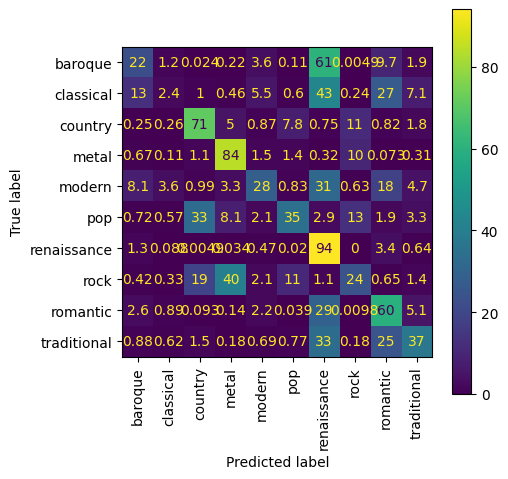

In [166]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
for i in range(10):
    confusion[i,:]/= confusion[i,:].sum() 
    confusion[i,:]*=100
disp = ConfusionMatrixDisplay(confusion_matrix=cp.asnumpy(confusion),display_labels=genres)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax,xticks_rotation='vertical')


In [167]:
del x